# Neighbor-number distribution over the last 1.5 us

This notebook independently analyzes the intermolecular neighbor-number distribution for `alhx_700`, `alhx_800`, and `alhx_1000` using the last 1.5 us of every trajectory.

/home/jychen/anaconda3/envs/CJY/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


alhx_700: loaded cached data from /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/EN_modeltest/diff_k_neighb/combined_alhx_700_last_1.5us.txt (225150 points)
alhx_800: loaded cached data from /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/EN_modeltest/diff_k_neighb/combined_alhx_800_last_1.5us.txt (150100 points)
alhx_1000: loaded cached data from /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/EN_modeltest/diff_k_neighb/combined_alhx_1000_last_1.5us.txt (150100 points)
Using font: Arial
                n_points  mean_n  std_n  median_n  min_n  max_n
system                                                         
IDP50_baseline   1500150  13.131  4.081      13.0      0     31
alhx_700          225150  10.873  3.269      11.0      0     25
alhx_800          150100  10.912  3.181      11.0      0     25
alhx_1000         150

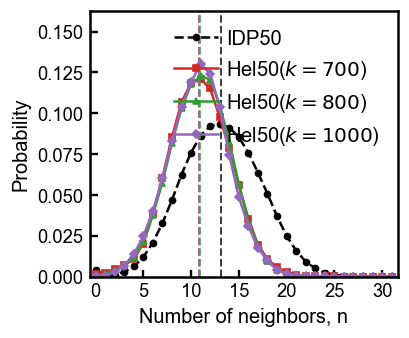

In [1]:
# Independent analysis: neighbor-number distributions from the last 1.5 us

import os
import sys
from pathlib import Path

import MDAnalysis as mda
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from MDAnalysis.lib.distances import distance_array
from matplotlib.ticker import MaxNLocator


# =========================
# User settings
# =========================
BASE_DIR = Path('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP')
W_CLUSTER_DIR = BASE_DIR / 'W_cluster'
OUT_DIR = BASE_DIR / 'Analysis/EN_modeltest/diff_k_neighb'
OUT_DIR.mkdir(parents=True, exist_ok=True)
IDP_BASELINE_FILE = BASE_DIR / 'Analysis/inter-chain/combined_alhx_0.txt'

# Analyze the last 1.5 us of each trajectory. MDAnalysis reports GROMACS time in ps.
LAST_WINDOW_US = 1.5
LAST_WINDOW_PS = LAST_WINDOW_US * 1_000_000.0

STRIDE = 1
CUTOFF_DISTANCE = 8.0
SELECTION_CRITERIA = 'protein and name BB'
RESIDUES_PER_CHAIN = 140
FORCE_SPLIT_BY_RESIDUE = True
REUSE_EXISTING_DATA = True

# Figure preset: single_small / single_medium / double_short / double_medium / double_large
FIG_PRESET = 'single_medium'

ARIAL_TTF_PATH = '/data/jychen/package/Arial/arial.ttf'
USE_ARIAL_TTF = True

SYSTEMS = {
    '700': {
        'label': r'Hel50($k=700$)',
        'color': '#d62728',
        'marker': 's',
        'topology': W_CLUSTER_DIR / 'alhx_700/TR_Mdvwhole/pbc.tpr',
        'trajectories': [
            W_CLUSTER_DIR / 'alhx_700/TR_Mdvwhole/clus_centered.xtc',
            W_CLUSTER_DIR / 'alhx_700_re1/TR_Mdvwhole/clus_centered.xtc',
            W_CLUSTER_DIR / 'alhx_700_re2/TR_Mdvwhole/clus_centered.xtc',
        ],
    },
    '800': {
        'label': r'Hel50($k=800$)',
        'color': '#2ca02c',
        'marker': '^',
        'topology': W_CLUSTER_DIR / 'alhx_800/TR_mdvwhole/pbc.tpr',
        'trajectories': [
            W_CLUSTER_DIR / 'alhx_800/TR_mdvwhole/clus_centered.xtc',
            W_CLUSTER_DIR / 'alhx_800_re1/TR_mdvwhole/clus_centered.xtc',
        ],
    },
    '1000': {
        'label': r'Hel50($k=1000$)',
        'color': '#9467bd',
        'marker': 'D',
        'topology': W_CLUSTER_DIR / 'alhx_1000/TR_mdvwhole/pbc.tpr',
        'trajectories': [
            W_CLUSTER_DIR / 'alhx_1000/TR_mdvwhole/clus_centered.xtc',
            W_CLUSTER_DIR / 'alhx_1000_re1/TR_mdvwhole/clus_centered.xtc',
        ],
    },
}


# =========================
# Publication figure style
# =========================
_PUB_FONT_NAME = None

def load_pub_font():
    global _PUB_FONT_NAME
    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME
    if USE_ARIAL_TTF and os.path.exists(ARIAL_TTF_PATH):
        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = 'Arial'
    print(f'Using font: {_PUB_FONT_NAME}')
    return _PUB_FONT_NAME

def mm_to_inch(mm):
    return mm / 25.4

FIG_SIZE = {'single': 90, 'double': 180}
FIG_PRESETS = {
    'single_small': ('single', 60),
    'single_medium': ('single', 75),
    'double_short': ('double', 70),
    'double_medium': ('double', 100),
    'double_large': ('double', 140),
}

def set_pub_style():
    pub_font = load_pub_font()
    mpl.rcParams.update({
        'font.family': pub_font,
        'font.sans-serif': [pub_font, 'Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
        'font.weight': 'normal',
        'axes.labelweight': 'normal',
        'axes.titleweight': 'normal',
        'font.size': 11,
        'axes.labelsize': 12,
        'axes.titlesize': 12,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 10,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
        'axes.linewidth': 1.5,
        'xtick.major.width': 1.4,
        'ytick.major.width': 1.4,
        'xtick.major.size': 4.5,
        'ytick.major.size': 4.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'lines.linewidth': 1.7,
        'legend.frameon': False,
        'legend.handlelength': 1.5,
        'legend.handletextpad': 0.4,
        'axes.unicode_minus': False,
        'axes.spines.top': True,
        'axes.spines.right': True,
        'savefig.dpi': 600,
        'figure.dpi': 120,
    })

def new_figure(preset=FIG_PRESET):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    fig, ax = plt.subplots(figsize=(mm_to_inch(FIG_SIZE[mode]), mm_to_inch(height_mm)))
    return fig, ax

def savefig_pub(fig, filename, dpi=600, tight=True):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches='tight', pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# =========================
# Analysis helpers
# =========================
def get_protein_chains(u, residues_per_chain=140, force_split_by_residue=True):
    protein_all = u.select_atoms('protein')
    if protein_all.n_atoms == 0:
        raise ValueError("No atoms found with selection 'protein'.")

    if not force_split_by_residue:
        chains = protein_all.split('molecule')
        if len(chains) > 1:
            print(f"  split('molecule') detected {len(chains)} chains.")
            return chains

    all_residues = protein_all.residues
    total_residues = len(all_residues)
    if total_residues % residues_per_chain != 0:
        raise ValueError(
            f'Protein residue count ({total_residues}) is not divisible by '
            f'RESIDUES_PER_CHAIN ({residues_per_chain}).'
        )

    num_chains = total_residues // residues_per_chain
    chains = []
    for chain_idx in range(num_chains):
        start_idx = chain_idx * residues_per_chain
        end_idx = (chain_idx + 1) * residues_per_chain
        chains.append(all_residues[start_idx:end_idx].atoms)
    print(f'  Split by residue count: {num_chains} chains, {residues_per_chain} residues/chain.')
    return chains

def get_last_window_start_frame(u, last_window_ps):
    n_frames = len(u.trajectory)
    first_time = float(u.trajectory[0].time)
    last_time = float(u.trajectory[-1].time)
    start_time = last_time - last_window_ps

    if start_time <= first_time:
        print(
            f'  Trajectory length is {(last_time - first_time) / 1_000_000.0:.3f} us; '
            f'use all {n_frames} frames.'
        )
        return 0, first_time, last_time

    for frame_idx, ts in enumerate(u.trajectory):
        if float(ts.time) >= start_time:
            print(
                f'  Use last {last_window_ps / 1_000_000.0:.3f} us: '
                f'time {ts.time / 1_000_000.0:.3f}-{last_time / 1_000_000.0:.3f} us, '
                f'frames {frame_idx}-{n_frames - 1}.'
            )
            return frame_idx, float(ts.time), last_time

    return max(0, n_frames - 1), last_time, last_time

def analyze_topology(u, start_frame, stride, cutoff, selection, residues_per_chain=140, force_split_by_residue=True):
    traj_slice = u.trajectory[start_frame::stride]
    n_analysis_frames = len(traj_slice)
    print(f'  Analyze frames: {start_frame} -> end, stride={stride}; n_frames={n_analysis_frames}')
    if n_analysis_frames == 0:
        return np.array([], dtype=int)

    protein_chains = get_protein_chains(u, residues_per_chain, force_split_by_residue)
    num_chains = len(protein_chains)
    chain_selections = [chain.select_atoms(selection) for chain in protein_chains]
    empty_chain_ids = [idx + 1 for idx, chain_sel in enumerate(chain_selections) if chain_sel.n_atoms == 0]
    if empty_chain_ids:
        raise ValueError(f'Empty atom selections for chains: {empty_chain_ids}; selection={selection!r}')

    all_neighbor_counts = []
    for i, ts in enumerate(traj_slice, start=1):
        adj_matrix = np.zeros((num_chains, num_chains), dtype=bool)
        for chain_idx_1 in range(num_chains):
            pos_1 = chain_selections[chain_idx_1].positions
            for chain_idx_2 in range(chain_idx_1 + 1, num_chains):
                pos_2 = chain_selections[chain_idx_2].positions
                if np.any(distance_array(pos_1, pos_2) < cutoff):
                    adj_matrix[chain_idx_1, chain_idx_2] = True
                    adj_matrix[chain_idx_2, chain_idx_1] = True

        all_neighbor_counts.extend(np.sum(adj_matrix, axis=1))
        sys.stdout.write(f'\r  Progress: {i}/{n_analysis_frames} (frame={ts.frame}, time={ts.time / 1_000_000.0:.3f} us)')
        sys.stdout.flush()

    print('\n  Done.')
    return np.array(all_neighbor_counts, dtype=int)

def combined_header(system_id, cfg, data, traj_info):
    lines = [
        f'Neighbor count distribution for alhx_{system_id}',
        f'Window: last {LAST_WINDOW_US:.3f} us of each trajectory',
        f'Cutoff_A: {CUTOFF_DISTANCE}',
        f'Selection: {SELECTION_CRITERIA}',
        'Source trajectories:',
    ]
    for row in traj_info:
        lines.append(
            f"- {row['trajectory']} | start_frame={row['start_frame']} | "
            f"time_us={row['start_time_ps'] / 1_000_000.0:.3f}-{row['last_time_ps'] / 1_000_000.0:.3f}"
        )
    lines.extend([
        '-' * 30,
        f'Statistics: Mean={np.mean(data):.3f}, StdDev={np.std(data, ddof=1):.3f}',
        'Data column: Neighbor_Counts',
    ])
    return '\n'.join(lines)

def analyze_and_cache_system(system_id, cfg):
    data_file = OUT_DIR / f'combined_alhx_{system_id}_last_{LAST_WINDOW_US:g}us.txt'
    info_file = OUT_DIR / f'trajectory_window_alhx_{system_id}_last_{LAST_WINDOW_US:g}us.csv'

    if REUSE_EXISTING_DATA and data_file.exists():
        data = np.atleast_1d(np.loadtxt(data_file, dtype=int))
        print(f'alhx_{system_id}: loaded cached data from {data_file} ({data.size} points)')
        return data

    missing = [path for path in [cfg['topology'], *cfg['trajectories']] if not path.exists()]
    if missing:
        raise FileNotFoundError('Missing input files:\n' + '\n'.join(str(path) for path in missing))

    all_results = []
    traj_info = []
    print('=' * 70)
    print(f'alhx_{system_id}: analyzing {len(cfg["trajectories"])} trajectories')
    print('=' * 70)

    for idx, traj_file in enumerate(cfg['trajectories'], start=1):
        print(f'\n--- alhx_{system_id} trajectory {idx}/{len(cfg["trajectories"])} ---')
        print(f'  {traj_file}')
        u = mda.Universe(str(cfg['topology']), str(traj_file))
        start_frame, start_time_ps, last_time_ps = get_last_window_start_frame(u, LAST_WINDOW_PS)
        results = analyze_topology(
            u=u,
            start_frame=start_frame,
            stride=STRIDE,
            cutoff=CUTOFF_DISTANCE,
            selection=SELECTION_CRITERIA,
            residues_per_chain=RESIDUES_PER_CHAIN,
            force_split_by_residue=FORCE_SPLIT_BY_RESIDUE,
        )
        if results.size > 0:
            all_results.append(results)
            traj_info.append({
                'system': f'alhx_{system_id}',
                'trajectory': str(traj_file),
                'n_total_frames': len(u.trajectory),
                'start_frame': start_frame,
                'start_time_ps': start_time_ps,
                'last_time_ps': last_time_ps,
                'n_data_points': int(results.size),
                'mean_n': float(results.mean()),
                'std_n': float(results.std(ddof=1)),
            })

    if not all_results:
        raise RuntimeError(f'alhx_{system_id}: no neighbor-count data were generated')

    data = np.concatenate(all_results)
    np.savetxt(data_file, data, fmt='%d', header=combined_header(system_id, cfg, data, traj_info))
    pd.DataFrame(traj_info).to_csv(info_file, index=False)
    print(f'alhx_{system_id}: saved data to {data_file} ({data.size} points)')
    print(f'alhx_{system_id}: saved trajectory-window info to {info_file}')
    return data


# =========================
# Run analysis and plot
# =========================
neighbor_data = {system_id: analyze_and_cache_system(system_id, cfg) for system_id, cfg in SYSTEMS.items()}
idp_data = np.atleast_1d(np.loadtxt(IDP_BASELINE_FILE, dtype=int))

x_min = int(min([idp_data.min(), *(data.min() for data in neighbor_data.values())]))
x_max = int(max([idp_data.max(), *(data.max() for data in neighbor_data.values())]))
x = np.arange(x_min, x_max + 1)

idp_counts = np.bincount(idp_data - x_min, minlength=len(x)).astype(float)
idp_prob = idp_counts / idp_counts.sum()

prob_data = {}
summary_rows = [{
    'system': 'IDP50_baseline',
    'n_points': int(idp_data.size),
    'mean_n': float(idp_data.mean()),
    'std_n': float(idp_data.std(ddof=1)),
    'median_n': float(np.median(idp_data)),
    'min_n': int(idp_data.min()),
    'max_n': int(idp_data.max()),
}]
for system_id, data in neighbor_data.items():
    counts = np.bincount(data - x_min, minlength=len(x)).astype(float)
    prob_data[system_id] = counts / counts.sum()
    summary_rows.append({
        'system': f'alhx_{system_id}',
        'n_points': int(data.size),
        'mean_n': float(data.mean()),
        'std_n': float(data.std(ddof=1)),
        'median_n': float(np.median(data)),
        'min_n': int(data.min()),
        'max_n': int(data.max()),
    })

fig, ax = new_figure(FIG_PRESET)
marker_size = 3.6
linewidth = mpl.rcParams.get('axes.linewidth', 1.5)
fs_label = mpl.rcParams.get('axes.labelsize', 10)
fs_tick = mpl.rcParams.get('xtick.labelsize', 9)

idp_mean_n = float(idp_data.mean())
ax.plot(
    x, idp_prob,
    color='black', marker='o', markersize=marker_size,
    linewidth=linewidth, linestyle='--', label='IDP50',
)
ax.axvline(idp_mean_n, color='black', linestyle='--', alpha=0.75, linewidth=1.2)

for system_id, cfg in SYSTEMS.items():
    mean_n = float(neighbor_data[system_id].mean())
    ax.plot(
        x, prob_data[system_id],
        color=cfg['color'], marker=cfg['marker'], markersize=marker_size,
        linewidth=linewidth, label=cfg['label'],
    )
    ax.axvline(mean_n, color=cfg['color'], linestyle='--', alpha=0.75, linewidth=1.2)

ax.set_xlabel('Number of neighbors, n', fontsize=fs_label)
ax.set_ylabel('Probability', fontsize=fs_label)
ax.xaxis.set_major_locator(MaxNLocator(nbins=7, integer=True))
ymax = max([idp_prob.max(), *(prob.max() for prob in prob_data.values())])
ax.set_ylim(0.0, ymax * 1.25)
ax.tick_params(axis='both', which='major', labelsize=fs_tick)
ax.legend(frameon=False, handlelength=2.2, fontsize=fs_label, loc='upper right')
ax.margins(x=0.02)
fig.tight_layout()

out_png = OUT_DIR / f'neighbor_distribution_IDP_700_800_1000_last_{LAST_WINDOW_US:g}us.png'
out_pdf = OUT_DIR / f'neighbor_distribution_IDP_700_800_1000_last_{LAST_WINDOW_US:g}us.pdf'
savefig_pub(fig, out_png, tight=True)
savefig_pub(fig, out_pdf, tight=True)

summary = pd.DataFrame(summary_rows).set_index('system')
summary_file = OUT_DIR / f'neighbor_distribution_summary_IDP_700_800_1000_last_{LAST_WINDOW_US:g}us.csv'
summary.to_csv(summary_file)

print(summary.round(3))
means = summary['mean_n']
print(f'Mean neighbor-number range across parameters: {means.min():.3f} - {means.max():.3f}')
print(f'Largest mean shift: {means.max() - means.min():.3f}')
print(f'Saved summary: {summary_file}')
print(f'Saved figure: {out_png}')
print(f'Saved figure: {out_pdf}')

plt.show()



